# Tree-Based Models: Decision Tree, enhanced by Bagging and Boosting

**Task:** sarcasm detection on Reddit comments (balanced SARC subset).

**Pipeline:** load data → clean → sample → train/test split → TF-IDF → train models → evaluate

| Stage | What happens | Why |
|---|---|---|
| Load + inspect | read parquet, check columns / nulls / label balance | know the data before modelling |
| Clean | drop nulls, empty text, duplicates | duplicates leaking across train/test inflate scores |
| Sample | stratified sample (`SAMPLE_N`) | fast iteration; scale up later |
| Split | stratified train/test **before** TF-IDF | vectorizer must only learn vocabulary from train (no leakage) |
| Encode | TF-IDF inside a sklearn `Pipeline` | split-safe, reusable, one `.fit()` call |
| Models | Decision Tree → Bagging → Random Forest → AdaBoost → Gradient Boosting | single tree is the baseline, ensembles fix its variance (bagging) or bias (boosting) |
| Evaluate | accuracy, F1, ROC-AUC, fit time | compare on equal footing |

> Run cells **top to bottom**. (The earlier `NameError: pd is not defined` happened because the read cell ran before the import cell.)

## 1. Setup

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
)
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, ConfusionMatrixDisplay
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


In [2]:
DATA_PATH     = "../../data/processed/reddit_sarc_balanced_full.parquet"
LABEL_COL     = "label"
COMMENT_COL   = "comment_clean"
PARENT_COL    = "parent_clean"
SUBREDDIT_COL = "subreddit"
USE_SUBREDDIT = True          # one-hot subreddit as an extra feature
SAMPLE_N      = 40_000
TEST_SIZE     = 0.2
RANDOM_STATE  = 42

MAX_FEATURES  = 3_000         # per text column (6,000 total)
NGRAM_RANGE   = (1, 2)
MIN_DF        = 5

## 2. Load and inspect

In [3]:
df = pd.read_parquet(DATA_PATH)
print("shape:", df.shape)
df.head()

shape: (916769, 46)


,label,comment_clean,parent_clean,subreddit,author,score,ups,downs,ups_is_missing,downs_is_missing,...,parent_n_words,parent_n_chars,parent_is_empty,parent_jaccard,len_ratio_to_parent,had_slash_s,had_label_hashtag,had_explicit_sarcasm_word,en_score,lang_method
0,0,NC and NH.,"Yeah, I get that argument. At this point, I'd ...",politics,Trumpbart,2.0,-1.0,-1.0,True,True,...,17,80,False,0.052632,0.176471,False,False,False,1.000000,heuristic-high
1,0,You do know west teams play against west teams...,The blazers and Mavericks (The wests 5 and 6 s...,nba,Shbshb906,-4.0,-1.0,-1.0,True,True,...,25,134,False,0.032258,0.560000,False,False,False,0.900000,heuristic-high
2,0,"They were underdogs earlier today, but since G...",They're favored to win.,nfl,Creepeth,3.0,3.0,0.0,False,False,...,4,23,False,0.047619,4.500000,False,False,False,0.990278,heuristic-high
3,0,"This meme isn't funny none of the ""new york ni...",deadass don't kill my buzz,BlackPeopleTwitter,icebrotha,-8.0,-1.0,-1.0,True,True,...,5,26,False,0.000000,2.400000,False,False,False,1.000000,heuristic-high
4,0,I could use one of those tools.,Yep can confirm I saw the tool they use for th...,MaddenUltimateTeam,cush2push,6.0,-1.0,-1.0,True,True,...,19,85,False,0.083333,0.368421,False,False,False,1.000000,heuristic-high


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 916769 entries, 0 to 916768
Data columns (total 46 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   label                      916769 non-null  int8          
 1   comment_clean              916769 non-null  str           
 2   parent_clean               916769 non-null  str           
 3   subreddit                  916769 non-null  string        
 4   author                     916769 non-null  string        
 5   score                      916769 non-null  float32       
 6   ups                        916769 non-null  float32       
 7   downs                      916769 non-null  float32       
 8   ups_is_missing             916769 non-null  bool          
 9   downs_is_missing           916769 non-null  bool          
 10  is_controversial           916769 non-null  bool          
 11  date                       916769 non-null  string        
 12 

## 4. Sample + train/test split
Stratified so the label balance is preserved in both the sample and the split.

In [5]:
feature_cols = [COMMENT_COL, PARENT_COL] + ([SUBREDDIT_COL] if USE_SUBREDDIT else [])

if SAMPLE_N and len(df) > SAMPLE_N:
    df_s, _ = train_test_split(
        df, train_size=SAMPLE_N, stratify=df[LABEL_COL], random_state=RANDOM_STATE
    )
else:
    df_s = df

X_train, X_test, y_train, y_test = train_test_split(
    df_s[feature_cols], df_s[LABEL_COL],
    test_size=TEST_SIZE, stratify=df_s[LABEL_COL], random_state=RANDOM_STATE,
)
print(f"train: {len(X_train):,}   test: {len(X_test):,}")

train: 32,000   test: 8,000


## 5. Feature engineering: TF-IDF
Wrapped in a function that returns a **fresh** vectorizer per model, so each `Pipeline` fits TF-IDF on training text only.

Notes on the choices:
- `sublinear_tf=True` dampens very frequent words.
- Stop words are **kept**: words like "oh", "totally", "sure" are often the sarcasm signal.
- `max_features` is capped because tree training cost scales with feature count.

In [6]:
def make_features():
    def tfidf():
        return TfidfVectorizer(ngram_range=NGRAM_RANGE, min_df=MIN_DF,
                               max_features=MAX_FEATURES, sublinear_tf=True)
    transformers = [
        ("comment", tfidf(), COMMENT_COL),    # string, not list, for text columns
        ("parent",  tfidf(), PARENT_COL),
    ]
    if USE_SUBREDDIT:
        transformers.append(("subreddit",
            OneHotEncoder(handle_unknown="ignore", min_frequency=50), [SUBREDDIT_COL]))
    return ColumnTransformer(transformers)

_f = make_features().fit(X_train)
print("train matrix:", _f.transform(X_train).shape)

train matrix: (32000, 6099)


## 6. Train models
A single decision tree is the baseline. The ensembles build on it:

- **Bagging / Random Forest**: many deep trees on bootstrap samples, averaged → lowers variance.
- **AdaBoost / Gradient Boosting**: many shallow trees built sequentially, each correcting the last → lowers bias.

A majority-class dummy is included as a floor (should land near 0.50 on a balanced set).

In [7]:
models = {
    "Dummy (majority)": DummyClassifier(strategy="most_frequent"),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=20, min_samples_leaf=5, random_state=RANDOM_STATE
    ),
    "Bagging (trees)": BaggingClassifier(
        estimator=DecisionTreeClassifier(min_samples_leaf=5),
        n_estimators=50, n_jobs=-1, random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, min_samples_leaf=2, n_jobs=-1, random_state=RANDOM_STATE
    ),
    "AdaBoost": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=2),
        n_estimators=200, learning_rate=0.5, random_state=RANDOM_STATE,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150, max_depth=3, learning_rate=0.1,
        subsample=0.8, max_features="sqrt", random_state=RANDOM_STATE,
    ),
}

fitted, rows = {}, []
for name, clf in models.items():
    pipe = Pipeline([("features", make_features()), ("clf", clf)])   # <- changed
    t0 = time.time()
    pipe.fit(X_train, y_train)          # X_train is now a DataFrame, not a Series
    fit_s = time.time() - t0

    pred  = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, proba),
        "train_acc": accuracy_score(y_train, pipe.predict(X_train)),
        "fit_seconds": round(fit_s, 1),
    })
    fitted[name] = pipe
    print(f"done: {name:<20} acc={rows[-1]['accuracy']:.3f}  ({fit_s:.1f}s)")

done: Dummy (majority)     acc=0.509  (2.7s)
done: Decision Tree        acc=0.582  (5.3s)
done: Bagging (trees)      acc=0.625  (378.9s)
done: Random Forest        acc=0.660  (52.7s)
done: AdaBoost             acc=0.600  (84.8s)
done: Gradient Boosting    acc=0.656  (10.8s)


## 7. Compare results
`train_acc` far above `accuracy` means overfitting (expected for the single deep tree and bagging).

In [8]:
results = pd.DataFrame(rows).set_index("model").sort_values("roc_auc", ascending=False)
results.round(3)

,accuracy,f1,roc_auc,train_acc,fit_seconds
model,,,,,
Random Forest,0.660,0.656,0.718,0.972,52.7
Gradient Boosting,0.656,0.632,0.705,0.669,10.8
Bagging (trees),0.626,0.613,0.680,0.943,378.9
AdaBoost,0.600,0.465,0.634,0.604,84.8
Decision Tree,0.582,0.442,0.597,0.641,5.3
Dummy (majority),0.509,0.675,0.500,0.509,2.7


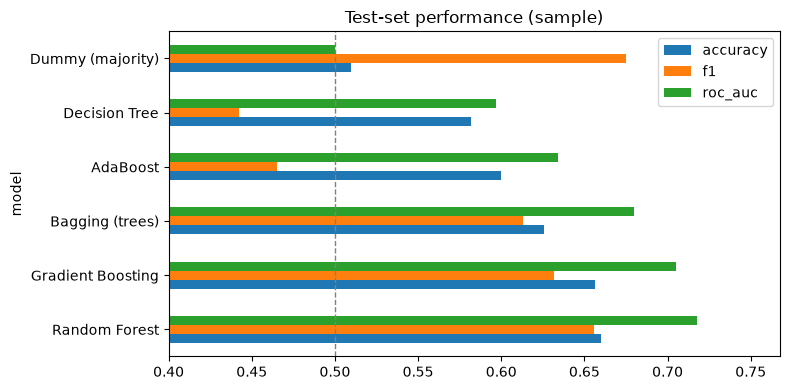

In [9]:
ax = results[["accuracy", "f1", "roc_auc"]].plot.barh(figsize=(8, 4))
ax.set_xlim(0.4, max(0.7, results["roc_auc"].max() + 0.05))
ax.axvline(0.5, color="grey", ls="--", lw=1)
ax.set_title("Test-set performance (sample)")
plt.tight_layout()
plt.show()

## 8. Inspect the best model

best by ROC-AUC: Random Forest


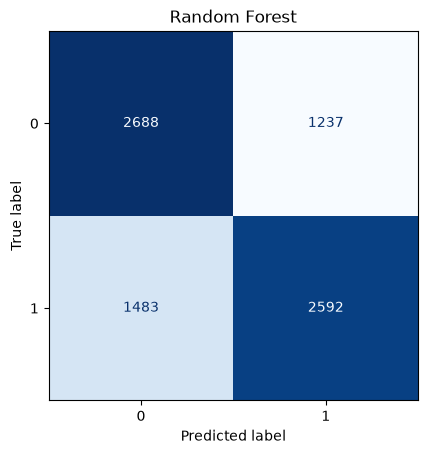

In [10]:
best_name = results.index[0]
print("best by ROC-AUC:", best_name)
ConfusionMatrixDisplay.from_estimator(
    fitted[best_name], X_test, y_test, cmap="Blues", colorbar=False
)
plt.title(best_name)
plt.show()

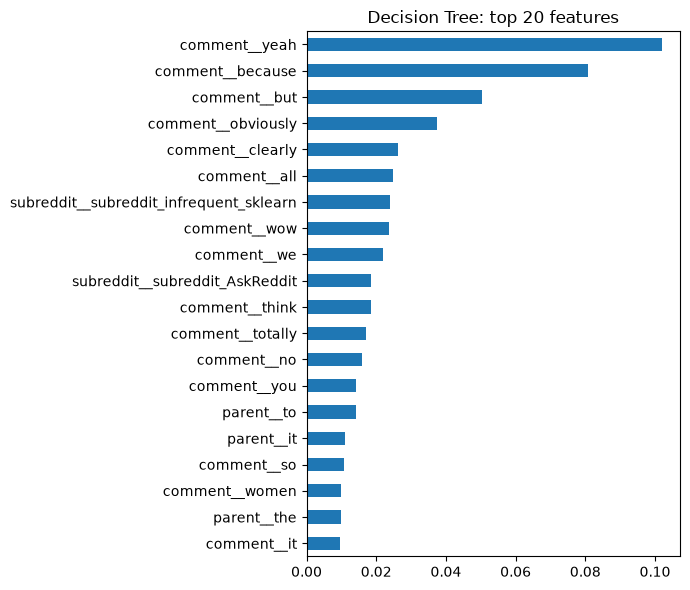

In [11]:
# Which words does the single decision tree lean on most?
tree_pipe = fitted["Decision Tree"]
words = np.array(tree_pipe["features"].get_feature_names_out())   # prefixed: comment__, parent__, subreddit__
imp = tree_pipe["clf"].feature_importances_
top = np.argsort(imp)[::-1][:20]
pd.Series(imp[top], index=words[top]).iloc[::-1].plot.barh(figsize=(7, 6), title="Decision Tree: top 20 features")
plt.tight_layout(); plt.show()

## Next steps
- Scale up: set `SAMPLE_N = None` once the pipeline is happy.
- Tune the top 2 models (`RandomizedSearchCV` over depth, `n_estimators`, `learning_rate`, `max_features`), using cross-validation on train only.
- Try `HistGradientBoosting` / LightGBM / XGBoost (much faster than sklearn `GradientBoostingClassifier` on large data).
- Add non-TF-IDF features: comment length, punctuation counts (`!`, `?`, `...`), ALL-CAPS ratio, and the parent comment / subreddit if available. Sarcasm depends heavily on context.
- Compare against a linear baseline (logistic regression on the same TF-IDF); on sparse text it often beats trees, which is a useful sanity check.